In [1]:
import numpy as np
from pathlib import Path
import napari
from liffile import LifFile
from skimage.filters import sobel


In [2]:
class FindInFocusPlane:
    """Load a LIF image, estimate a quadratic focal surface on a downsampled grid,
    produce a downsampled focused preview, and extract a Z-slab centered on a
    global best-focus slice (preserving original integer Z slices).

    Usage:
        ref = FindInFocusPlane(lif_path, image_index=0, downsample=4, n_sampling=20, patch=50)
        cropped, focus_ds, grid_ds, global_z0 = ref.run(z_range_um=200)
    """

    def __init__(self, lif_path, image_index=0, downsample=4, n_sampling=20, patch=50, channel_axis=None, z_step_override=None):
        self.lif_path = Path(lif_path)
        self.image_index = int(image_index)
        self.downsample = int(downsample)
        self.n_sampling = int(n_sampling)
        self.patch = int(patch)
        self.channel_axis = channel_axis
        self.z_step_override = None if z_step_override is None else float(z_step_override)

        self._loaded = False
        self.sampled_z_counts = {}

    def _step(self, axis, xa):
        if axis not in xa.coords or xa.coords[axis].size < 2:
            return None
        return float(xa.coords[axis][1] - xa.coords[axis][0])

    def load(self):
        with LifFile(self.lif_path) as lif:
            if self.image_index < 0 or self.image_index >= len(lif.images):
                raise IndexError('image_index out of range')
            img = lif.images[self.image_index]
            image = img.asarray()
            xa = img.asxarray()

            # read z-step if available (liffile coordinates typically in meters)
            x_um = self._step('X', xa)
            z_um = self._step('Z', xa)
            if z_um is not None:
                z_um = z_um * 1e6

        arr = np.asarray(image)

        # normalize to (Z, Y, X[, C])
        if arr.ndim == 2:
            stack = arr[np.newaxis, ...]
        elif arr.ndim == 3:
            if arr.shape[0] < 64:
                stack = arr
            else:
                stack = arr[np.newaxis, ...]
        elif arr.ndim == 4:
            if self.channel_axis is not None and self.channel_axis != 3:
                stack = np.moveaxis(arr, self.channel_axis, -1)
            else:
                stack = arr
        else:
            raise ValueError(f'Unsupported array shape: {arr.shape}')

        self.stack = stack
        self.nz, self.ny, self.nx = stack.shape[:3]
        self.z_step_um = self.z_step_override if self.z_step_override is not None else (z_um if z_um is not None else None)
        if self.z_step_um is None:
            raise RuntimeError('Could not determine Z step (um) from LIF metadata; pass z_step_override')

        # prepare downsampled stack for autofocus scoring
        ds = max(1, self.downsample)
        if ds > 1:
            if self.stack.ndim == 3:
                self.stack_ds = self.stack[:, ::ds, ::ds]
            else:
                self.stack_ds = self.stack[:, ::ds, ::ds, ...]
        else:
            self.stack_ds = self.stack

        self._loaded = True

    def _to_gray(self, im):
        if im.ndim == 2:
            return im
        return np.mean(im, axis=-1)

    def focus_score(self, patch):
        p = np.asarray(self._to_gray(patch), dtype=float)
        s = sobel(p)
        return float(np.std(s))

    def best_focus_slice(self, stack_zyx, mask=None):
        Z = stack_zyx.shape[0]
        scores = []
        for z in range(Z):
            sl = self._to_gray(stack_zyx[z])
            if mask is not None:
                sl = sl * mask
            scores.append(np.std(sobel(sl)))
        z0 = int(np.argmax(scores))
        return z0, self._to_gray(stack_zyx[z0])

    def curved_plane_refocus(self, stack_zyx, grid=None, patch=None, mask=None):
        # quadratic surface: z = ax^2 + by^2 + cxy + dx + ey + f
        if grid is None:
            grid = self.n_sampling
        if patch is None:
            patch = self.patch
        Z, H, W = stack_zyx.shape
        ys = np.linspace(patch // 2, H - patch // 2 - 1, grid).astype(int)
        xs = np.linspace(patch // 2, W - patch // 2 - 1, grid).astype(int)

        pts, zs = [], []
        for y in ys:
            for x in xs:
                if mask is not None and not mask[y, x]:
                    continue
                sl = (slice(y - patch // 2, y + patch // 2), slice(x - patch // 2, x + patch // 2))
                f = np.array([self.focus_score(stack_zyx[z][sl]) for z in range(Z)], dtype=np.float32)
                pts.append((x, y))
                zs.append(int(np.argmax(f)))

        if len(zs) < 6:
            z0, img = self.best_focus_slice(stack_zyx, mask=mask)
            zmap = np.full(stack_zyx.shape[1:], z0, dtype=np.int16)
            return img, zmap, np.array(pts), np.array(zs)

        pts = np.array(pts, dtype=np.float32)
        zs = np.array(zs, dtype=np.float32)

        # normalize coordinates to improve conditioning (use downsampled H,W)
        Xc = pts[:, 0] - pts[:, 0].mean()
        Yc = pts[:, 1] - pts[:, 1].mean()
        scale = max(W, H)
        Xn = Xc / scale
        Yn = Yc / scale

        B = np.column_stack((Xn**2, Yn**2, Xn * Yn, Xn, Yn, np.ones_like(Xn)))
        coeffs, *_ = np.linalg.lstsq(B, zs, rcond=None)

        # evaluate surface on full downsampled grid (normalized coordinates)
        Xg, Yg = np.meshgrid(np.arange(W), np.arange(H))
        mean_x = pts[:, 0].mean()
        mean_y = pts[:, 1].mean()
        Xg_n = (Xg - mean_x) / scale
        Yg_n = (Yg - mean_y) / scale
        zmap = (coeffs[0] * Xg_n**2 + coeffs[1] * Yg_n**2 + coeffs[2] * Xg_n * Yg_n
                + coeffs[3] * Xg_n + coeffs[4] * Yg_n + coeffs[5])
        zmap = np.clip(np.rint(zmap).astype(np.int16), 0, Z - 1)
        img = np.take_along_axis(stack_zyx, zmap[None, :, :], axis=0)[0]
        return img, zmap, pts, zs

    def compute_grid_and_focus(self):
        if not self._loaded:
            self.load()

        # compute global best-focus on the full-resolution intensity stack (preserve original z sampling)
        if self.stack.ndim == 4:
            stack_score_full = np.mean(self.stack, axis=-1)
        else:
            stack_score_full = self.stack
        self.global_z0, _ = self.best_focus_slice(stack_score_full, mask=None)

        # prepare score stack (grayscale) for downsampled autofocus
        if self.stack_ds.ndim == 4:
            stack_ds_score = np.mean(self.stack_ds, axis=-1)
        else:
            stack_ds_score = self.stack_ds

        focus_ds, grid_ds, pts, zs = self.curved_plane_refocus(stack_ds_score, grid=self.n_sampling, patch=self.patch, mask=None)
        self.grid_ds = np.clip(grid_ds, 0, self.nz - 1)

        # reconstruct downsampled focused image from stack_ds (this may contain artifacts)
        if self.stack_ds.ndim == 3:
            self.focus_ds_out = np.take_along_axis(self.stack_ds, self.grid_ds[None, :, :], axis=0)[0]
        else:
            self.focus_ds_out = np.take_along_axis(self.stack_ds, self.grid_ds[None, :, :, None], axis=0)[0]

        return self.focus_ds_out, self.grid_ds, pts, zs

    def crop_stack(self, z_range_um):
        if not hasattr(self, 'global_z0'):
            raise RuntimeError('global best-focus not computed; call compute_grid_and_focus() first')

        z_range_px = max(1, int(round(z_range_um / float(self.z_step_um))))
        half = z_range_px // 2
        deltas = np.arange(z_range_px) - half

        # build z index volume centered on the global best-focus slice (preserve original integer z slices)
        z_idx = (self.global_z0 + deltas)[:, None, None]
        z_idx = np.clip(z_idx, 0, self.nz - 1).astype(int)

        # create matching y/x indices via arange + broadcast using full-res dims
        ny, nx = self.ny, self.nx
        Zc = z_idx.shape[0]
        y_idx = np.broadcast_to(np.arange(ny)[None, :, None], (Zc, ny, nx))
        x_idx = np.broadcast_to(np.arange(nx)[None, None, :], (Zc, ny, nx))

        # advanced indexing: works for (Z,Y,X) and (Z,Y,X,C)
        cropped = self.stack[z_idx, y_idx, x_idx]
        return cropped

    def run(self, z_range_um=200):
        focus_ds, grid_ds, pts, zs = self.compute_grid_and_focus()

        # print requested diagnostics
        print(f'Global best z (slice): {getattr(self, "global_z0", None)}')
        if zs is None or len(zs) == 0:
            print('No sampled best-z values available from curved_plane_refocus()')
            min_z = max_z = None
            self.sampled_z_counts = {}
        else:
            zs_arr = np.asarray(zs, dtype=int)
            min_z = int(zs_arr.min())
            max_z = int(zs_arr.max())
            print(f'Sampled best-z range from in-focus patches: {min_z} .. {max_z} (n={zs_arr.size})')

            # compute counts per sampled z value and store on the instance
            unique, counts = np.unique(zs_arr, return_counts=True)
            counts_dict = {int(int(u)): int(int(c)) for u, c in zip(unique, counts)}
            self.sampled_z_counts = counts_dict
            print('Sample counts per z (z:count):', counts_dict)

        # warn if provided z_range_um doesn't include all sampled best-zs
        if getattr(self, 'global_z0', None) is not None and (min_z is not None):
            z_range_px = max(1, int(round(z_range_um / float(self.z_step_um))))
            half = z_range_px // 2
            lower = self.global_z0 - half
            upper = self.global_z0 + half
            if (min_z < lower) or (max_z > upper):
                print(f"WARNING: requested z_range_um={z_range_um}um ({z_range_px} slices) centered on global_z0={self.global_z0} does NOT include sampled best-zs range ({min_z}..{max_z}). Consider increasing z_range_um.")

        cropped = self.crop_stack(z_range_um)
        return cropped, focus_ds, grid_ds, getattr(self, 'global_z0', None)

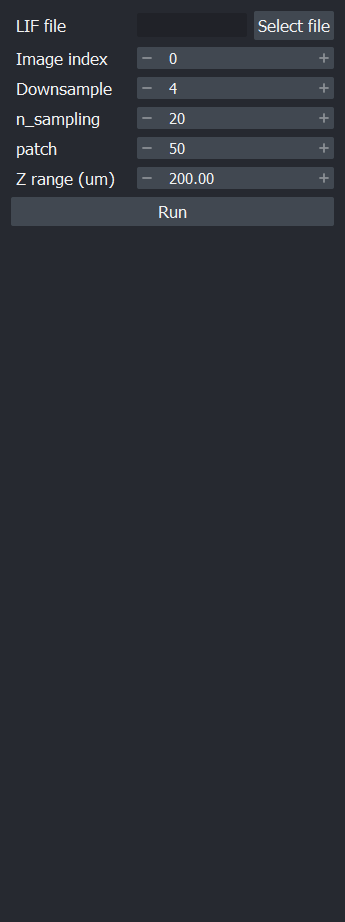

Global best z (slice): 8
Sampled best-z range from in-focus patches: 0 .. 27 (n=400)
Sample counts per z (z:count): {0: 18, 1: 4, 2: 5, 3: 2, 4: 1, 5: 5, 6: 12, 7: 25, 8: 51, 9: 50, 10: 44, 11: 61, 12: 45, 13: 22, 14: 19, 15: 14, 16: 4, 17: 3, 18: 2, 19: 2, 20: 2, 21: 1, 22: 1, 24: 1, 25: 2, 26: 1, 27: 3}
grid_ds shape: (1634, 944) global_z0: 8
Done — check Napari layers


In [3]:
# Run quadratic refit (object-oriented) and visualize grid map via magicgui
from magicgui import magicgui
from pathlib import Path

# create a napari Viewer to host the GUI (dock the widget here)
viewer = napari.Viewer()

@magicgui(lif_file={'label': 'LIF file', 'mode': 'r', 'filter': '*.lif'}, image_index={'label': 'Image index', 'min': 0, 'step': 1}, downsample={'label':'Downsample', 'min':1, 'max':16, 'step':1}, n_sampling={'label':'n_sampling','min':4,'max':100,'step':1}, patch={'label':'patch','min':1,'max':512,'step':1}, z_range_um={'label':'Z range (um)','min':1,'step':1})
def run_ref(lif_file: Path = None, image_index: int = 0, downsample: int = 4, n_sampling: int = 20, patch: int = 50, z_range_um: float = 200.0):
    if lif_file is None or not Path(lif_file).exists():
        print('No LIF selected')
        return
    lif_path = Path(lif_file)
    ref = FindInFocusPlane(lif_path, image_index=image_index, downsample=downsample, n_sampling=n_sampling, patch=patch, z_step_override=None)
    cropped, focus_ds, grid_ds, global_z0 = ref.run(z_range_um=z_range_um)

    print('grid_ds shape:', grid_ds.shape, 'global_z0:', global_z0)

    # remove prior layers with the same names if present
    existing_names = {lay.name: lay for lay in viewer.layers}
    for name in ('focus_quad_ds', 'grid_quad', 'cropped_slab'):
        if name in existing_names:
            try:
                viewer.layers.remove(existing_names[name])
            except Exception:
                pass

    # add layers to the docked viewer
    viewer.add_image(focus_ds, name='focus_quad_ds')
    viewer.add_image(grid_ds, name='grid_quad')
    viewer.add_image(cropped, name='cropped_slab')
    print('Done — check Napari layers')

# dock the magicgui into the viewer's window on the right
viewer.window.add_dock_widget(run_ref.native, area='right')

# show the widget (if running outside the docked context it still provides UI)
run_ref.show()

In [ ]:
try:
    print('cropped.shape =', cropped.shape)
except NameError:
    print('cropped is not defined (run the demo cell)')


(8, 6533, 3775)

In [ ]:
try:
    print('focus_ds shape =', focus_ds.shape)
except NameError:
    print('focus_ds is not defined (run the demo cell)')


array([[  0,  94,  92, ..., 106, 108, 112],
       [  0,  95,  96, ..., 107, 108, 108],
       [  0,  96,  95, ..., 104, 108, 108],
       ...,
       [104, 108, 108, ..., 126, 127, 128],
       [105, 108, 108, ..., 130, 132, 132],
       [  0,   0,   0, ..., 131, 131, 133]],
      shape=(1634, 944), dtype=uint8)

In [ ]:
# Napari viewer helper: the demo cell already launches Napari and shows results.
# If you want to re-open the viewer after running the demo, call:
#
# import napari
# viewer = napari.Viewer()
# viewer.add_image(focus_ds, name='focus_quad_ds')
# viewer.add_image(grid_full, name='grid_quad')
# viewer.add_image(cropped, name='cropped_slab')

print('Viewer helper cell — run the demo cell to display results in Napari')


<Image layer 'grid_full' at 0x17bc24a3250>